In [1]:
import pandas as pd
print("Pandas is Working")

Pandas is Working


In [2]:
import pandas as pd
df = pd.read_csv("../data/sample_emails_with_triage_200.csv")
df.head()

,id,sender,subject,body,priority,triage_label
0,1,alerts@bank.com,Password Reset Request,Reminder: The client meeting is scheduled at 1...,low,notify_human
1,2,alerts@bank.com,Congratulations! You've Won,Your invoice of INR 25515.09 is due on 2025-12...,low,respond
2,3,no-reply@service.com,Promotion: Big Sale,Reminder: The client meeting is scheduled at 1...,low,ignore
3,4,sales@shop.com,Monthly Report,"Hello team, please find the attached weekly re...",medium,respond
4,5,no-reply@service.com,Survey,"Hello team, please find the attached weekly re...",low,respond


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            200 non-null    int64 
 1   sender        200 non-null    object
 2   subject       200 non-null    object
 3   body          200 non-null    object
 4   priority      200 non-null    object
 5   triage_label  200 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.5+ KB


In [8]:
df["triage_label"].value_counts()


triage_label
notify_human    91
respond         66
ignore          43
Name: count, dtype: int64

In [7]:
df["priority"].value_counts()


priority
low       119
medium     64
high       17
Name: count, dtype: int64

In [9]:
high_priority = df[df["priority"] == "high"]
high_priority.head()


,id,sender,subject,body,priority,triage_label
8,9,security@bank.com,Account Suspended,"Dear user, we detected a login from a new devi...",high,notify_human
10,11,support@cloud.com,Survey,Reminder: The client meeting is scheduled at 1...,high,respond
18,19,teamlead@company.com,Congratulations! You've Won,Please complete the mandatory training module ...,high,respond
20,21,support@cloud.com,Account Suspended,Notice: Your account will be locked unless ver...,high,notify_human
30,31,news@techblog.com,Weekly Newsletter,Notice: Your account will be locked unless ver...,high,notify_human


In [11]:
important_cols = df[["subject", "sender"]]
important_cols.head()

,subject,sender
0,Password Reset Request,alerts@bank.com
1,Congratulations! You've Won,alerts@bank.com
2,Promotion: Big Sale,no-reply@service.com
3,Monthly Report,sales@shop.com
4,Survey,no-reply@service.com


In [12]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'triage_label'], dtype='object')

In [13]:
df.info


<bound method DataFrame.info of       id                sender                      subject  \
0      1       alerts@bank.com       Password Reset Request   
1      2       alerts@bank.com  Congratulations! You've Won   
2      3  no-reply@service.com          Promotion: Big Sale   
3      4        sales@shop.com               Monthly Report   
4      5  no-reply@service.com                       Survey   
..   ...                   ...                          ...   
195  196  no-reply@service.com                Policy Update   
196  197      boss@company.com                Order Shipped   
197  198  no-reply@service.com            Weekly Newsletter   
198  199     news@techblog.com              Payment Overdue   
199  200     support@cloud.com          Promotion: Big Sale   

                                                  body priority  triage_label  
0    Reminder: The client meeting is scheduled at 1...      low  notify_human  
1    Your invoice of INR 25515.09 is due on 2025-12

In [14]:
df.describe(include="all")

,id,sender,subject,body,priority,triage_label
count,200.000000,200,200,200,200,200
unique,NaN,10,20,59,3,3
top,NaN,no-reply@service.com,Action Required,Notice: Your account will be locked unless ver...,low,notify_human
freq,NaN,26,17,24,119,91
mean,100.500000,NaN,NaN,NaN,NaN,NaN
std,57.879185,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,50.750000,NaN,NaN,NaN,NaN,NaN
50%,100.500000,NaN,NaN,NaN,NaN,NaN
75%,150.250000,NaN,NaN,NaN,NaN,NaN


In [20]:
df["triage_label"].value_counts()


triage_label
notify_human    91
respond         66
ignore          43
Name: count, dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            200 non-null    int64 
 1   sender        200 non-null    object
 2   subject       200 non-null    object
 3   body          200 non-null    object
 4   priority      200 non-null    object
 5   triage_label  200 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.5+ KB


In [22]:
df.shape

(200, 6)

In [23]:
df.isnull().sum()

id              0
sender          0
subject         0
body            0
priority        0
triage_label    0
dtype: int64

In [25]:
df['body'][0]


'Reminder: The client meeting is scheduled at 10:00 tomorrow. Prepare your slides.'

In [28]:
df['priority'].value_counts()

priority
low       119
medium     64
high       17
Name: count, dtype: int64

In [29]:
df['clean_text'] = df['body'].str.lower().str.replace(r'[^a-zA-Z]', ' ', regex=True)


In [31]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'triage_label',
       'clean_text'],
      dtype='object')

In [30]:
df['clean_text'] = df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)
df[['body','clean_text']].head()

,body,clean_text
0,Reminder: The client meeting is scheduled at 1...,remindertheclientmeetingisscheduledattomorrowp...
1,Your invoice of INR 25515.09 is due on 2025-12...,yourinvoiceofinrisdueonpleasepaytoavoidlatefees
2,Reminder: The client meeting is scheduled at 1...,remindertheclientmeetingisscheduledattomorrowp...
3,"Hello team, please find the attached weekly re...",helloteampleasefindtheattachedweeklyreportanda...
4,"Hello team, please find the attached weekly re...",helloteampleasefindtheattachedweeklyreportanda...


In [32]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq.most_common(15)

[('remindertheclientmeetingisscheduledattomorrowprepareyourslides', 24),
 ('yourorderhasbeenshippedandisexpectedtodeliverby', 24),
 ('noticeyouraccountwillbelockedunlessverificationiscompleted', 24),
 ('congratulationsyouhavebeenselectedasaluckywinnerclaimyourprizenowbyclickingthelink',
  23),
 ('securityalertmultiplefailedloginattemptswererecordedonyouraccount', 22),
 ('pleasecompletethemandatorytrainingmodulebeforethedeadline', 19),
 ('hidontmissoursalewithdiscountsuptoonselecteditemsclicktoknowmore', 19),
 ('dearuserwedetectedaloginfromanewdeviceifthiswasntyouresetyourpasswordimmediately',
  16),
 ('yourinvoiceofinrisdueonpleasepaytoavoidlatefees', 15),
 ('helloteampleasefindtheattachedweeklyreportandactionitemsfortheproject', 14)]

In [33]:
all_words_text = "".join(df['clean_text'])

In [35]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'triage_label',
       'clean_text'],
      dtype='object')

In [7]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'label'], dtype='object')

In [36]:
df['clean_text'] = df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)
df[['body','clean_text']].head()

,body,clean_text
0,Reminder: The client meeting is scheduled at 1...,remindertheclientmeetingisscheduledattomorrowp...
1,Your invoice of INR 25515.09 is due on 2025-12...,yourinvoiceofinrisdueonpleasepaytoavoidlatefees
2,Reminder: The client meeting is scheduled at 1...,remindertheclientmeetingisscheduledattomorrowp...
3,"Hello team, please find the attached weekly re...",helloteampleasefindtheattachedweeklyreportanda...
4,"Hello team, please find the attached weekly re...",helloteampleasefindtheattachedweeklyreportanda...


In [37]:
all_words_text = " ".join(df['clean_text'])

In [38]:
words = all_words_text.split()

In [39]:
len(words)

200

In [41]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import nltk

In [43]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\theer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
import re

df['clean_text'] = (
    df['body']
    .str.lower()                              
    .str.replace(r'[^a-z\s]', '', regex=True) 
    .str.replace(r'\s+', ' ', regex=True)     
    .str.strip()
)
print(df['clean_text'])

0      reminder the client meeting is scheduled at to...
1      your invoice of inr is due on please pay to av...
2      reminder the client meeting is scheduled at to...
3      hello team please find the attached weekly rep...
4      hello team please find the attached weekly rep...
                             ...                        
195    security alert multiple failed login attempts ...
196    your order has been shipped and is expected to...
197    congratulations you have been selected as a lu...
198    please complete the mandatory training module ...
199    congratulations you have been selected as a lu...
Name: clean_text, Length: 200, dtype: object


In [47]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\theer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\theer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
from nltk.tokenize import wordpunct_tokenize

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""
    words = wordpunct_tokenize(text.lower())
    return " ".join([w for w in words if w.isalpha() and w not in stop_words])

df['clean_text'] = df['body'].fillna("").apply(remove_stopwords)

In [49]:
print(df['clean_text'])

0      reminder client meeting scheduled tomorrow pre...
1             invoice inr due please pay avoid late fees
2      reminder client meeting scheduled tomorrow pre...
3      hello team please find attached weekly report ...
4      hello team please find attached weekly report ...
                             ...                        
195    security alert multiple failed login attempts ...
196                       order shipped expected deliver
197    congratulations selected lucky winner claim pr...
198    please complete mandatory training module dead...
199    congratulations selected lucky winner claim pr...
Name: clean_text, Length: 200, dtype: object


In [50]:

df['clean_text'].head(3)

0    reminder client meeting scheduled tomorrow pre...
1           invoice inr due please pay avoid late fees
2    reminder client meeting scheduled tomorrow pre...
Name: clean_text, dtype: object

In [51]:
from collections import Counter

# Combine 
all_words = " ".join(df['clean_text']).split()

# Count word frequency
word_freq = Counter(all_words)

# Convert to DataFrame
word_freq_df = (
    pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
    .sort_values(by='Frequency', ascending=False)
)

# Show top 10 words
word_freq_df.head(10)

,Word,Frequency
10,please,48
57,account,46
25,selected,42
39,login,38
22,items,33
2,meeting,24
1,client,24
0,reminder,24
3,scheduled,24
34,expected,24


In [52]:
from collections import Counter
all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq_df = (pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
                .sort_values(by='Frequency', ascending=False))
word_freq_df.head()

,Word,Frequency
10,please,48
57,account,46
25,selected,42
39,login,38
22,items,33


In [53]:
# 3. Remove stopwords using NLTK
stop_words = set(stopwords.words("english"))

def remove_stopwords(text: str) -> str:
    words = text.split()                      # simple tokenization
    filtered = [w for w in words if w not in stop_words]
    return " ".join(filtered)

df["clean_no_stop"] = df["clean_text"].apply(remove_stopwords)

# 4. Show first 3 rows
print("First 3 rows:")
print(df.head(3))

First 3 rows:
   id                sender                      subject  \
0   1       alerts@bank.com       Password Reset Request   
1   2       alerts@bank.com  Congratulations! You've Won   
2   3  no-reply@service.com          Promotion: Big Sale   

                                                body priority  triage_label  \
0  Reminder: The client meeting is scheduled at 1...      low  notify_human   
1  Your invoice of INR 25515.09 is due on 2025-12...      low       respond   
2  Reminder: The client meeting is scheduled at 1...      low        ignore   

                                          clean_text  \
0  reminder client meeting scheduled tomorrow pre...   
1         invoice inr due please pay avoid late fees   
2  reminder client meeting scheduled tomorrow pre...   

                                       clean_no_stop  
0  reminder client meeting scheduled tomorrow pre...  
1         invoice inr due please pay avoid late fees  
2  reminder client meeting scheduled t

In [54]:
# 5. Analyze word frequency (using clean text without stopwords)
all_words = " ".join(df["clean_no_stop"]).split()
word_freq = Counter(all_words)
print("Top 10 frequent words:\n", word_freq.most_common(10))

Top 10 frequent words:
 [('please', 48), ('account', 46), ('selected', 42), ('login', 38), ('items', 33), ('reminder', 24), ('client', 24), ('meeting', 24), ('scheduled', 24), ('tomorrow', 24)]


In [55]:
#spam key word detection
spam_keywords = ["offer", "free", "win", "discount", "cashback", "prize", "limited"]

def check_spam(text):
    text = text.lower()
    return any(keyword in text for keyword in spam_keywords)

df['spam_detected'] = df['body'].apply(check_spam)
df[['subject','spam_detected']].head()


,subject,spam_detected
0,Password Reset Request,False
1,Congratulations! You've Won,False
2,Promotion: Big Sale,False
3,Monthly Report,False
4,Survey,False


In [56]:
#stemming
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def stem_text(text):
    if not isinstance(text, str):
        return ""
    # we can stem from clean_text 
    words = text.split()
    stemmed_words = [ps.stem(w) for w in words]
    return " ".join(stemmed_words)

df["stemmed"] = df["clean_text"].apply(stem_text)

print("\nSample Stemming:")
print(df[["clean_text", "stemmed"]].head())



Sample Stemming:
                                          clean_text  \
0  reminder client meeting scheduled tomorrow pre...   
1         invoice inr due please pay avoid late fees   
2  reminder client meeting scheduled tomorrow pre...   
3  hello team please find attached weekly report ...   
4  hello team please find attached weekly report ...   

                                             stemmed  
0   remind client meet schedul tomorrow prepar slide  
1            invoic inr due pleas pay avoid late fee  
2   remind client meet schedul tomorrow prepar slide  
3  hello team pleas find attach weekli report act...  
4  hello team pleas find attach weekli report act...  


In [57]:
!pip install matplotlib

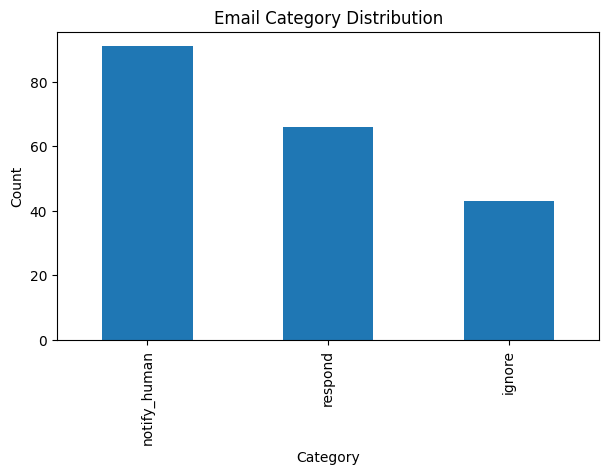

In [59]:
#Visualize Category Counts (Bar Chart)
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
df['triage_label'].value_counts().plot(kind='bar')
plt.title("Email Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()



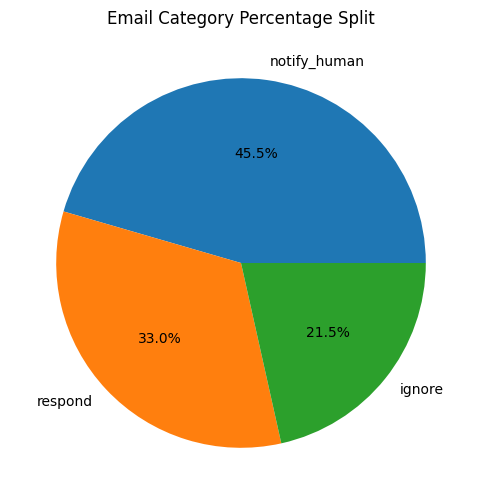

In [60]:
#Pie Chart Visualization
plt.figure(figsize=(6,6))
df['triage_label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Email Category Percentage Split")
plt.ylabel("")   # remove extra text
plt.show()

In [61]:
print(df.columns)

Index(['id', 'sender', 'subject', 'body', 'priority', 'triage_label',
       'clean_text', 'clean_no_stop', 'spam_detected', 'stemmed'],
      dtype='object')


In [63]:
#Extract Top 5 Keywords Per Category
from collections import Counter

def top_keywords(category):
    cat_text = " ".join(df[df['triage_label'] == category]['clean_no_stop']).split()
    freq = Counter(cat_text).most_common(5)
    return freq

for c in df['triage_label'].unique():
    print(f"\nTop Keywords in '{c}' category:")
    print(top_keywords(c))


Top Keywords in 'notify_human' category:
[('account', 46), ('login', 38), ('notice', 24), ('locked', 24), ('unless', 24)]

Top Keywords in 'respond' category:
[('please', 29), ('order', 19), ('shipped', 19), ('expected', 19), ('deliver', 19)]

Top Keywords in 'ignore' category:
[('selected', 33), ('congratulations', 20), ('lucky', 20), ('winner', 20), ('claim', 20)]


In [68]:
#4. Highlight Emails With Multiple Category Matches
#Find Top Keywords per Category
from collections import Counter

category_keywords = {}

for label in df['triage_label'].unique():
    
    words = " ".join(df[df['triage_label'] == label]['clean_no_stop']).split()
    
    
    freq = Counter(words).most_common(5)
    
    
    category_keywords[label] = [w for w, _ in freq]

category_keywords



{'notify_human': ['account', 'login', 'notice', 'locked', 'unless'],
 'respond': ['please', 'order', 'shipped', 'expected', 'deliver'],
 'ignore': ['selected', 'congratulations', 'lucky', 'winner', 'claim']}

In [69]:
# Find how many category keyword sets appear in each email
def matched_categories(text):
    text_words = set(text.split())   # convert email text to a set of words
    
    matches = []
    for category, keywords in category_keywords.items():
        if text_words & set(keywords):   # intersection → common words
            matches.append(category)
    
    return matches



In [66]:
#Filter emails that match more than one category
multi_match = df[df['match_count'] > 1]
multi_match[['subject', 'body', 'category_matches', 'match_count']]


,subject,body,category_matches,match_count


In [73]:
#Highlight them in Jupyter Notebook
df['category_matches'] = df['clean_no_stop'].apply(matched_categories)
df['match_count'] = df['category_matches'].apply(len)

df[['subject', 'body', 'category_matches', 'match_count']].head(10)

,subject,body,category_matches,match_count
0,Password Reset Request,Reminder: The client meeting is scheduled at 1...,[],0
1,Congratulations! You've Won,Your invoice of INR 25515.09 is due on 2025-12...,[respond],1
2,Promotion: Big Sale,Reminder: The client meeting is scheduled at 1...,[],0
3,Monthly Report,"Hello team, please find the attached weekly re...",[respond],1
4,Survey,"Hello team, please find the attached weekly re...",[respond],1
5,Unusual Login Attempt,Your invoice of INR 38766.88 is due on 2025-12...,[respond],1
6,Project Update,Congratulations! You have been selected as a l...,[ignore],1
7,Project Update,Your order #6313 has been shipped and is expec...,[respond],1
8,Account Suspended,"Dear user, we detected a login from a new devi...",[notify_human],1
9,Monthly Report,Your invoice of INR 32944.21 is due on 2025-12...,[respond],1
